# 02. Modele parametryczne i rozszerzenie bayesowskie

            Notebook odtwarza porównanie modeli AFT, profile przeżycia i hazardu, probability plots oraz demonstracyjny model bayesowski Weibulla z cenzurowaniem prawostronnym.


## Import bibliotek i przygotowanie danych


In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

# UWAGA:
# Plik z danymi powinien znajdować się najlepiej w tym samym folderze co notebook
# albo w podfolderze "data".
#
# Oczekiwana nazwa pliku:
# heart_failure_clinical_records_dataset.csv
#
# Kod nie używa bezwzględnych ścieżek Windows, dzięki czemu notebook powinien
# działać po przeniesieniu do dowolnego katalogu roboczego.

DATA_FILENAME = "heart_failure_clinical_records_dataset.csv"


def find_data_file(filename: str = DATA_FILENAME) -> Path:
    """
    Szuka pliku danych w typowych lokalizacjach względem katalogu roboczego
    i jego katalogów nadrzędnych.

    Priorytet:
    1. bieżący katalog roboczy,
    2. podfolder data,
    3. podfolder Data,
    4. katalogi nadrzędne,
    5. rekurencyjne wyszukiwanie w bieżącym katalogu i katalogach nadrzędnych.
    """
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]

    direct_candidates = []
    for root in search_roots:
        direct_candidates.extend([
            root / filename,
            root / "data" / filename,
            root / "Data" / filename,
        ])

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate.resolve()

    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0].resolve()

    raise FileNotFoundError(
        f"Nie znaleziono pliku danych: {filename}\n"
        "Umieść plik w tym samym folderze co notebook albo w podfolderze 'data'."
    )


DATA_PATH = find_data_file()

print(f"Wczytywany plik danych: {DATA_PATH}")

df = pd.read_csv(DATA_PATH).drop_duplicates().copy()

df["duration"] = df["time"].astype(float)
df["event"] = df["DEATH_EVENT"].astype(int)

df["age_60plus"] = (df["age"] >= 60).astype(int)
df["ef_low"] = (df["ejection_fraction"] < 35).astype(int)
df["creatinine_high"] = (df["serum_creatinine"] > 1.5).astype(int)
df["sodium_low"] = (df["serum_sodium"] < 135).astype(int)

df["log_cpk"] = np.log1p(df["creatinine_phosphokinase"])
df["log_platelets"] = np.log(df["platelets"])


def show(title, obj):
    print(f"\n{title}")
    print("-" * len(title))
    if isinstance(obj, pd.DataFrame):
        print(obj.to_string())
    elif isinstance(obj, pd.Series):
        print(obj.to_string())
    else:
        print(obj)


from lifelines import (
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
    ExponentialFitter,
    KaplanMeierFitter,
)
from scipy.stats import norm as scipy_norm
from scipy.stats import pearsonr

np.random.seed(2026)

cov_full = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "log_cpk",
]

cov_red = [
    "age",
    "anaemia",
    "ejection_fraction",
    "high_blood_pressure",
    "serum_creatinine",
    "serum_sodium",
]

full = df[["duration", "event"] + cov_full].copy()
red = df[["duration", "event"] + cov_red].copy()

show("Zmiennie w modelu pełnym", pd.Series(cov_full))
show("Zmiennie w modelu zredukowanym", pd.Series(cov_red))

Wczytywany plik danych: C:\Users\jakob\OneDrive\Pulpit\A_MAGISTERKA SGH\Analiza_czasu_trwania\PROJECT\ACT\Workspace\WERSJA_POPRAWIONA\jupyter_notebooks\heart_failure_clinical_records_dataset.csv

Zmiennie w modelu pełnym
------------------------
0                    age
1      ejection_fraction
2       serum_creatinine
3           serum_sodium
4                anaemia
5               diabetes
6    high_blood_pressure
7                    sex
8                smoking
9                log_cpk

Zmiennie w modelu zredukowanym
------------------------------
0                    age
1                anaemia
2      ejection_fraction
3    high_blood_pressure
4       serum_creatinine
5           serum_sodium


## Porównanie modeli parametrycznych


In [4]:
models = {
    "Weibull AFT pełny": WeibullAFTFitter(penalizer=0.01).fit(full, "duration", "event"),
    "Log-normal AFT": LogNormalAFTFitter(penalizer=0.01).fit(full, "duration", "event"),
    "Log-logistic AFT": LogLogisticAFTFitter(penalizer=0.01).fit(full, "duration", "event"),
    "Weibull AFT zredukowany": WeibullAFTFitter(penalizer=0.01).fit(red, "duration", "event"),
    "Wykładniczy bez kowariant": ExponentialFitter().fit(df["duration"], event_observed=df["event"]),
}
comparison = []
for name, model in models.items():
    comparison.append([name, model.log_likelihood_, model.AIC_, getattr(model, "BIC_", np.nan), len(model.params_) if hasattr(model, "params_") else 1])
comparison = pd.DataFrame(comparison, columns=["Model", "logLik", "AIC", "BIC", "Param."]).round(2)
comparison["Delta AIC vs Weibull pełny"] = (comparison["AIC"] - comparison.loc[comparison["Model"] == "Weibull AFT pełny", "AIC"].iloc[0]).round(2)
show("Porównanie modeli parametrycznych", comparison)

weibull_full = models["Weibull AFT pełny"]
weibull_red = models["Weibull AFT zredukowany"]
rho_hat = float(np.exp(weibull_full.params_.loc[("rho_", "Intercept")]))
show("Parametr kształtu Weibulla", pd.Series({"rho_hat": rho_hat}))



Porównanie modeli parametrycznych
---------------------------------
                       Model  logLik      AIC      BIC  Param.  Delta AIC vs Weibull pełny
0          Weibull AFT pełny -631.52  1287.04  1274.44      12                        0.00
1             Log-normal AFT -634.36  1292.72  1280.12      12                        5.68
2           Log-logistic AFT -633.04  1290.09  1277.49      12                        3.05
3    Weibull AFT zredukowany -632.13  1280.27  1275.67       8                       -6.77
4  Wykładniczy bez kowariant -672.54  1347.08  1350.78       1                       60.04

Parametr kształtu Weibulla
--------------------------
rho_hat    0.96937


## Parametry modeli Weibull AFT


In [5]:
def aft_summary(model):
    out = model.summary[["coef", "exp(coef)", "se(coef)", "p", "coef lower 95%", "coef upper 95%"]].copy()
    return out.round(4)

show("Parametry pełnego modelu Weibull AFT", aft_summary(weibull_full))
show("Parametry zredukowanego modelu Weibull AFT", aft_summary(weibull_red))

lr_like = pd.DataFrame({
    "model": ["pełny", "zredukowany"],
    "logLik": [weibull_full.log_likelihood_, weibull_red.log_likelihood_],
    "AIC": [weibull_full.AIC_, weibull_red.AIC_],
    "liczba parametrów": [len(weibull_full.params_), len(weibull_red.params_)],
}).round(3)
show("Model pełny i zredukowany", lr_like)



Parametry pełnego modelu Weibull AFT
------------------------------------
                               coef  exp(coef)  se(coef)       p  coef lower 95%  coef upper 95%
param   covariate                                                                               
lambda_ age                 -0.0468     0.9542    0.0096  0.0000         -0.0657         -0.0280
        anaemia             -0.4251     0.6537    0.2141  0.0471         -0.8448         -0.0054
        diabetes            -0.1073     0.8982    0.2239  0.6316         -0.5461          0.3315
        ejection_fraction    0.0485     1.0497    0.0109  0.0000          0.0272          0.0698
        high_blood_pressure -0.4773     0.6204    0.2161  0.0272         -0.9010         -0.0537
        log_cpk             -0.0707     0.9318    0.0995  0.4774         -0.2656          0.1243
        serum_creatinine    -0.3228     0.7242    0.0724  0.0000         -0.4646         -0.1809
        serum_sodium         0.0434     1.0443    0.

## Profile przeżycia i hazardu w modelu Weibull AFT



Profile pacjentów
-----------------
                age  anaemia  ejection_fraction  high_blood_pressure  serum_creatinine  serum_sodium
Niskie ryzyko    50        0                 45                    0               1.0           140
Średnie ryzyko   65        0                 35                    1               1.4           137
Wysokie ryzyko   75        1                 20                    1               2.2           132


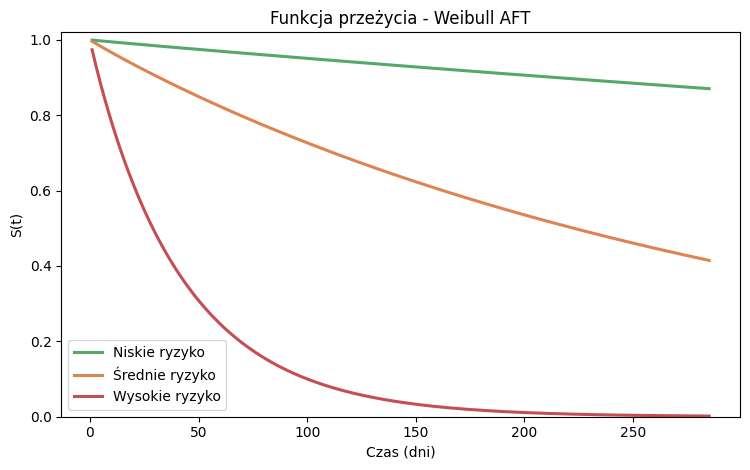

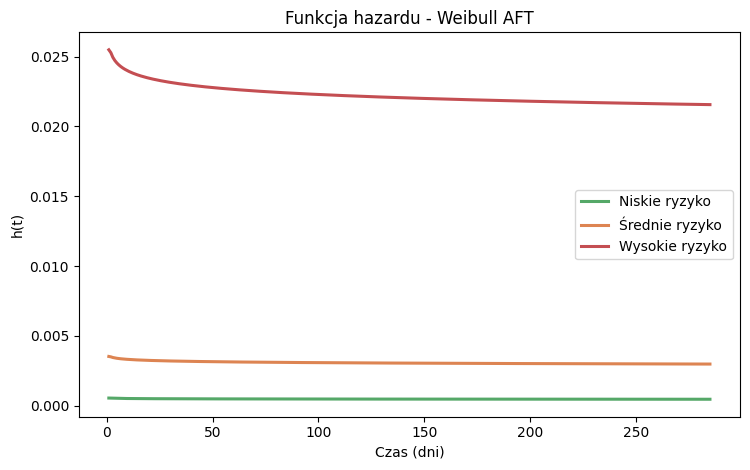

In [6]:
profiles = pd.DataFrame({
    "age": [50, 65, 75],
    "anaemia": [0, 0, 1],
    "ejection_fraction": [45, 35, 20],
    "high_blood_pressure": [0, 1, 1],
    "serum_creatinine": [1.0, 1.4, 2.2],
    "serum_sodium": [140, 137, 132],
}, index=["Niskie ryzyko", "Średnie ryzyko", "Wysokie ryzyko"])[cov_red]
show("Profile pacjentów", profiles)

colors = ["#55A868", "#DD8452", "#C44E52"]
t_grid = np.linspace(1, df["duration"].max(), 300)
sf = weibull_red.predict_survival_function(profiles, times=t_grid)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for (label, _), color in zip(profiles.iterrows(), colors):
    ax.plot(t_grid, sf[label].values, color=color, lw=2.2, label=label)
ax.set(title="Funkcja przeżycia - Weibull AFT", xlabel="Czas (dni)", ylabel="S(t)", ylim=(0, 1.02))
ax.legend()
plt.tight_layout()

ch = weibull_red.predict_cumulative_hazard(profiles, times=t_grid)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for (label, _), color in zip(profiles.iterrows(), colors):
    h = np.gradient(ch[label].values, t_grid)
    ax.plot(t_grid, h, color=color, lw=2.2, label=label)
ax.set(title="Funkcja hazardu - Weibull AFT", xlabel="Czas (dni)", ylabel="h(t)")
ax.legend()
plt.tight_layout()


## Probability plots



R^2 dla probability plots
-------------------------
      rozkład      R2  nachylenie
0     Weibull  0.9297       0.863
1  Log-normal  0.9802       0.502


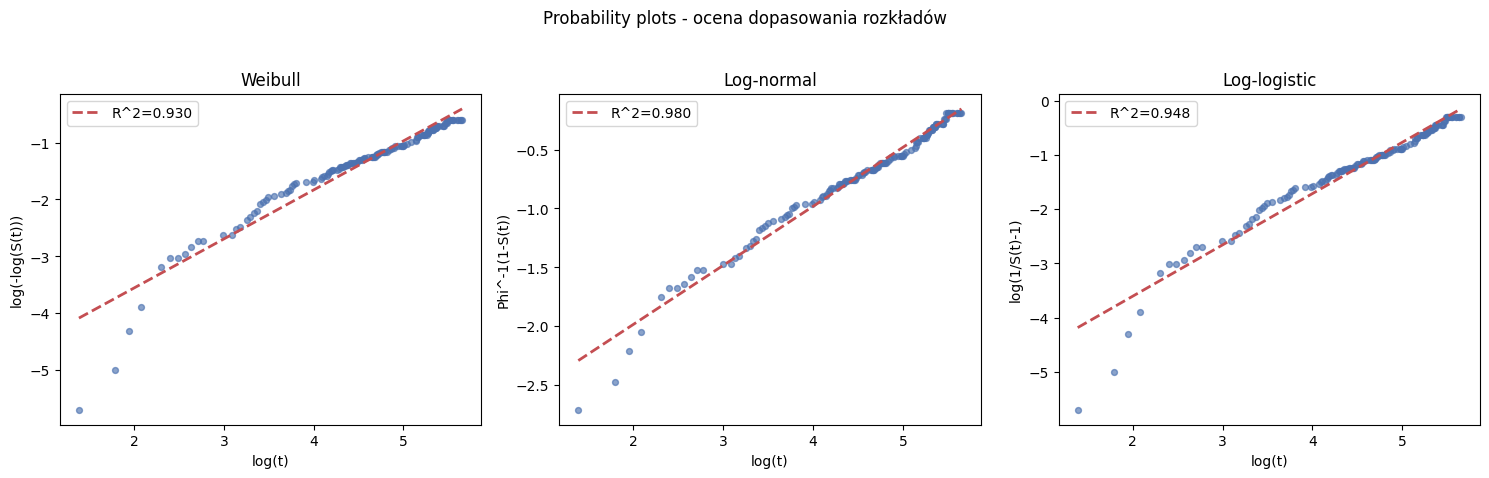

In [7]:
kmf = KaplanMeierFitter().fit(df["duration"], df["event"])
t_km = kmf.survival_function_.index.values
S_km = kmf.survival_function_["KM_estimate"].values
mask = (S_km > 0) & (S_km < 1) & (t_km > 0)
t_km, S_km = t_km[mask], S_km[mask]
log_t = np.log(t_km)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
r2_rows = []

y_w = np.log(-np.log(S_km))
sw, iw = np.polyfit(log_t, y_w, 1)
rw, _ = pearsonr(log_t, y_w)
axes[0].scatter(log_t, y_w, s=18, alpha=0.65, color="#4C72B0")
axes[0].plot(log_t, sw * log_t + iw, "--", color="#C44E52", lw=2, label=f"R^2={rw**2:.3f}")
axes[0].set(title="Weibull", xlabel="log(t)", ylabel="log(-log(S(t)))")
axes[0].legend()
r2_rows.append(["Weibull", rw**2, sw])

y_n = scipy_norm.ppf(1 - S_km)
sn, inn = np.polyfit(log_t, y_n, 1)
rn, _ = pearsonr(log_t, y_n)
axes[1].scatter(log_t, y_n, s=18, alpha=0.65, color="#4C72B0")
axes[1].plot(log_t, sn * log_t + inn, "--", color="#C44E52", lw=2, label=f"R^2={rn**2:.3f}")
axes[1].set(title="Log-normal", xlabel="log(t)", ylabel="Phi^-1(1-S(t))")
axes[1].legend()
r2_rows.append(["Log-normal", rn**2, sn])

y_l = np.log(1 / S_km - 1)
sl, il = np.polyfit(log_t, y_l, 1)
rl, _ = pearsonr(log_t, y_l)
axes[2].scatter(log_t, y_l, s=18, alpha=0.65, color="#4C72B0")
axes[2].plot(log_t, sl * log_t + il, "--", color="#C44E52", lw=2, label=f"R^2={rl**2:.3f}")
axes[2].set(title="Log-logistic", xlabel="log(t)", ylabel="log(1/S(t)-1)")
axes[2].legend()
fig.suptitle("Probability plots - ocena dopasowania rozkładów", y=1.03)
plt.tight_layout()

r2_table = pd.DataFrame(r2_rows, columns=["rozkład", "R2", "nachylenie"]).round(4)
show("R^2 dla probability plots", r2_table)


## Bayesowski model Weibulla



Posterior modelu bayesowskiego
------------------------------
                          mean      sd    q2.5     q50   q97.5  P(beta>0)
beta0                   6.3858  0.2009  6.0488  6.3582  6.8188     1.0000
beta_age               -0.5880  0.1212 -0.8584 -0.5792 -0.3632     0.0000
beta_ejection_fraction  0.6742  0.1620  0.3784  0.6640  1.0147     1.0000
beta_serum_creatinine  -0.3935  0.0769 -0.5544 -0.3936 -0.2397     0.0000
log_rho                -0.1192  0.0914 -0.3112 -0.1149  0.0476     0.0874

Parametry MCMC
--------------
łańcuchy                  2.0000
iteracje_na_łańcuch    3500.0000
burn_in                1000.0000
akceptacja_średnia        0.5339

Kierunki efektów w klasycznym Weibull AFT dla zmiennych bayesowskich
--------------------------------------------------------------------
                             coef
param   covariate                
lambda_ age               -0.0454
        ejection_fraction  0.0476
        serum_creatinine  -0.3105


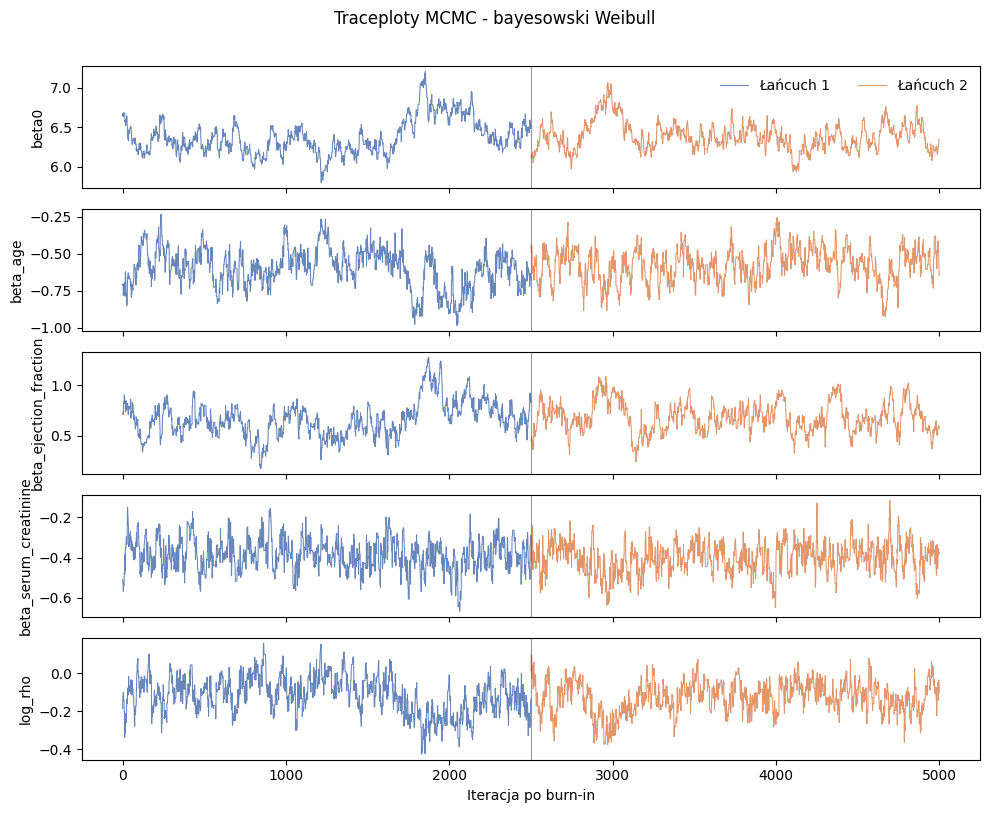

In [8]:
bayes_vars = ["age", "ejection_fraction", "serum_creatinine"]
X_raw = df[bayes_vars].copy()
X_mean = X_raw.mean()
X_std = X_raw.std()
X = ((X_raw - X_mean) / X_std).to_numpy()
t = df["duration"].to_numpy()
e = df["event"].to_numpy()
n, p = X.shape

def log_posterior(theta):
    beta0 = theta[0]
    beta = theta[1:1+p]
    log_rho = theta[-1]
    rho = np.exp(log_rho)
    eta = beta0 + X @ beta
    lam = np.exp(eta)
    z = (t / lam) ** rho
    ll = np.sum(e * (np.log(rho) - rho * np.log(lam) + (rho - 1) * np.log(t)) - z)
    prior_beta = -0.5 * np.sum(theta[:-1] ** 2 / 2.5 ** 2)
    prior_rho = -0.5 * (log_rho ** 2)
    return ll + prior_beta + prior_rho

def run_chain(seed, n_iter=3500, burn=1000, step=0.055):
    rng = np.random.default_rng(seed)
    theta = np.zeros(p + 2)
    current = log_posterior(theta)
    draws = []
    accepted = 0
    for i in range(n_iter):
        proposal = theta + rng.normal(0, step, size=theta.size)
        proposed = log_posterior(proposal)
        if np.log(rng.uniform()) < proposed - current:
            theta, current = proposal, proposed
            accepted += 1
        if i >= burn:
            draws.append(theta.copy())
    return np.asarray(draws), accepted / n_iter

chains, acc = [], []
for seed in [2026, 2027]:
    draw, ar = run_chain(seed)
    chains.append(draw)
    acc.append(ar)
posterior = np.vstack(chains)
names = ["beta0", *[f"beta_{v}" for v in bayes_vars], "log_rho"]
post = pd.DataFrame(posterior, columns=names)
summary = pd.DataFrame({
    "mean": post.mean(),
    "sd": post.std(),
    "q2.5": post.quantile(0.025),
    "q50": post.quantile(0.5),
    "q97.5": post.quantile(0.975),
    "P(beta>0)": [(post[c] > 0).mean() for c in post.columns],
}).round(4)
show("Posterior modelu bayesowskiego", summary)
show("Parametry MCMC", pd.Series({"łańcuchy": 2, "iteracje_na_łańcuch": 3500, "burn_in": 1000, "akceptacja_średnia": np.mean(acc)}).round(4))

fig, axes = plt.subplots(len(names), 1, figsize=(10, 8), sharex=True)
chain_colors = ["#4C72B0", "#DD8452"]
chain_labels = ["Łańcuch 1", "Łańcuch 2"]
chain_length = len(chains[0])
for ax, name in zip(axes, names):
    offset = 0
    for chain_id, draw in enumerate(chains):
        x = np.arange(offset, offset + len(draw))
        ax.plot(
            x,
            draw[:, names.index(name)],
            lw=0.75,
            alpha=0.85,
            color=chain_colors[chain_id],
            label=chain_labels[chain_id],
        )
        offset += len(draw)
    ax.axvline(chain_length, color="#444444", lw=0.8, alpha=0.55)
    ax.set_ylabel(name)
axes[0].legend(loc="upper right", ncol=2, frameon=False)
axes[-1].set_xlabel("Iteracja po burn-in")
fig.suptitle("Traceploty MCMC - bayesowski Weibull", y=1.01)
plt.tight_layout()

classic = weibull_red.summary.loc[("lambda_", ["age", "ejection_fraction", "serum_creatinine"]), ["coef"]].copy()
show("Kierunki efektów w klasycznym Weibull AFT dla zmiennych bayesowskich", classic.round(4))


## Wnioski kontrolne

            Porównanie AIC wskazuje model Weibull AFT jako podstawowy model parametryczny w prezentacji. Część bayesowska jest demonstracyjna, lecz faktycznie estymuje posterior z uwzględnieniem cenzurowania prawostronnego i pokazuje traceploty oraz prawdopodobieństwa posteriori.
